In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import os

Part 1 : Web Scraping

In [ ]:
base_url="http://books.toscrape.com/catalogue/page-{}.html"
books=[]
print("Starting web scraping...") 

for page in range(1,51): #50 pages=1000 books 
    url=base_url.format(page)
    response=requests.get(url)
    response.raise_for_status()
    soup=BeautifulSoup(response.text,'html.parser')

    articles=soup.find_all('article',class_='product_pod')

    for article in articles:
        title=article.h3.a['title']
        price_str=article.find('div',class_='product_price').find('p',class_='price_color').text.strip()
        price=float(price_str.replace('£','').replace('Â', '').strip())

        rating_class = article.find('p', class_='star-rating')['class'][1]
        rating_map = {'One':1, 'Two':2, 'Three':3, 'Four':4, 'Five':5}
        rating = rating_map.get(rating_class, 0)
        
        availability = article.find('p', class_='instock availability').text.strip()
        
        link = "http://books.toscrape.com/catalogue/" + article.h3.a['href']
        
        books.append({
            'title': title,
            'price': price,
            'rating': rating,
            'availability': availability,
            'product_url': link
        })
    
    print(f"Page {page} scraped ({len(books)} books so far)")
    time.sleep(1)  #Little delay to decrease server load 

# Save to CSV
df = pd.DataFrame(books)
df.to_csv('books_data_raw.csv', index=False)
print(f"Scraping completed! Saved {len(df)} records to books_data_raw.csv")


Starting web scraping...
Page 1 scraped (20 books so far)
Page 2 scraped (40 books so far)
Page 3 scraped (60 books so far)
Page 4 scraped (80 books so far)
Page 5 scraped (100 books so far)
Page 6 scraped (120 books so far)
Page 7 scraped (140 books so far)
Page 8 scraped (160 books so far)
Page 9 scraped (180 books so far)
Page 10 scraped (200 books so far)
Page 11 scraped (220 books so far)
Page 12 scraped (240 books so far)
Page 13 scraped (260 books so far)
Page 14 scraped (280 books so far)
Page 15 scraped (300 books so far)
Page 16 scraped (320 books so far)
Page 17 scraped (340 books so far)
Page 18 scraped (360 books so far)
Page 19 scraped (380 books so far)
Page 20 scraped (400 books so far)
Page 21 scraped (420 books so far)
Page 22 scraped (440 books so far)
Page 23 scraped (460 books so far)
Page 24 scraped (480 books so far)
Page 25 scraped (500 books so far)
Page 26 scraped (520 books so far)
Page 27 scraped (540 books so far)
Page 28 scraped (560 books so far)
Page 29 

2.Data Cleaning & Feature Engineering

In [ ]:
#Load raw data
Books=pd.read_csv(r"C:\Users\RISHABH SINGH\Desktop\PYTHON\books_data_raw.csv")

In [ ]:
#Standardising Titles of Columns
Books.columns=[cols.title() for cols in Books.columns]

In [15]:
Books

,Title,Price,Rating,Availability,Product_Url
0,A Light in the Attic,51.77,3,In stock,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,1,In stock,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,1,In stock,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,4,In stock,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,http://books.toscrape.com/catalogue/sapiens-a-...
...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,1,In stock,http://books.toscrape.com/catalogue/alice-in-w...
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,4,In stock,http://books.toscrape.com/catalogue/ajin-demi-...
997,A Spy's Devotion (The Regency Spies of London #1),16.97,5,In stock,http://books.toscrape.com/catalogue/a-spys-dev...
998,1st to Die (Women's Murder Club #1),53.98,1,In stock,http://books.toscrape.com/catalogue/1st-to-die...


In [16]:
#Check missing & duplicates

print("Missing values:\n", Books.isnull().sum())

Books= Books.drop_duplicates()

Missing values:
 Title           0
Price           0
Rating          0
Availability    0
Product_Url     0
dtype: int64


In [17]:
#Data type conversion

Books['Price'] = Books['Price'].astype(float)

Books['Rating'] = Books['Rating'].astype(int)

In [19]:
#Feature Engineering

Books['Stock_Status'] = np.where(Books['Availability'].str.contains('In stock'), 1, 0)

Books['Rating_Category'] = np.where(Books['Rating'] >= 4, 'High', 'Low')

Books['Price_Category'] = pd.cut(Books['Price'], bins=[0, 20, 40, 100], labels=['Budget', 'Medium', 'Premium'])

print(f"{Books['Stock_Status']} \n {Books['Rating_Category']} \n {Books['Price_Category']}")

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Stock_Status, Length: 1000, dtype: int64 
 0       Low
1       Low
2       Low
3      High
4      High
       ... 
995     Low
996    High
997    High
998     Low
999    High
Name: Rating_Category, Length: 1000, dtype: object 
 0      Premium
1      Premium
2      Premium
3      Premium
4      Premium
        ...   
995    Premium
996    Premium
997     Budget
998    Premium
999     Medium
Name: Price_Category, Length: 1000, dtype: category
Categories (3, object): ['Budget' < 'Medium' < 'Premium']


In [20]:
Books

,Title,Price,Rating,Availability,Product_Url,Stock_Status,Rating_Category,Price_Category
0,A Light in the Attic,51.77,3,In stock,http://books.toscrape.com/catalogue/a-light-in...,1,Low,Premium
1,Tipping the Velvet,53.74,1,In stock,http://books.toscrape.com/catalogue/tipping-th...,1,Low,Premium
2,Soumission,50.10,1,In stock,http://books.toscrape.com/catalogue/soumission...,1,Low,Premium
3,Sharp Objects,47.82,4,In stock,http://books.toscrape.com/catalogue/sharp-obje...,1,High,Premium
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,http://books.toscrape.com/catalogue/sapiens-a-...,1,High,Premium
...,...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,1,In stock,http://books.toscrape.com/catalogue/alice-in-w...,1,Low,Premium
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,4,In stock,http://books.toscrape.com/catalogue/ajin-demi-...,1,High,Premium
997,A Spy's Devotion (The Regency Spies of London #1),16.97,5,In stock,http://books.toscrape.com/catalogue/a-spys-dev...,1,High,Budget
998,1st to Die (Women's Murder Club #1),53.98,1,In stock,http://books.toscrape.com/catalogue/1st-to-die...,1,Low,Premium


In [21]:
#Save clean dataset

Books.to_csv('Books_Data_Clean.csv', index=False)

print("Clean dataset saved! Shape:", df.shape)

print(Books.head())

Clean dataset saved! Shape: (1000, 5)
                                   Title  Price  Rating Availability  \
0                   A Light in the Attic  51.77       3     In stock   
1                     Tipping the Velvet  53.74       1     In stock   
2                             Soumission  50.10       1     In stock   
3                          Sharp Objects  47.82       4     In stock   
4  Sapiens: A Brief History of Humankind  54.23       5     In stock   

                                         Product_Url  Stock_Status  \
0  http://books.toscrape.com/catalogue/a-light-in...             1   
1  http://books.toscrape.com/catalogue/tipping-th...             1   
2  http://books.toscrape.com/catalogue/soumission...             1   
3  http://books.toscrape.com/catalogue/sharp-obje...             1   
4  http://books.toscrape.com/catalogue/sapiens-a-...             1   

  Rating_Category Price_Category  
0             Low        Premium  
1             Low        Premium  
2  

In [6]:
Books_Clean.to_csv('Books_Final.csv', index=False)

In [2]:
#New cleaned data 
Books_Clean=pd.read_csv(r"C:\Users\RISHABH SINGH\Desktop\PYTHON\Books_Data_Clean.csv")

In [5]:
Books_Clean

,Title,Price,Rating,Availability,Product_Url,Stock_Status,Rating_Category,Price_Category,Cluster
0,A Light in the Attic,51.77,3,In stock,http://books.toscrape.com/catalogue/a-light-in...,1,Low,Premium,2
1,Tipping the Velvet,53.74,1,In stock,http://books.toscrape.com/catalogue/tipping-th...,1,Low,Premium,2
2,Soumission,50.10,1,In stock,http://books.toscrape.com/catalogue/soumission...,1,Low,Premium,1
3,Sharp Objects,47.82,4,In stock,http://books.toscrape.com/catalogue/sharp-obje...,1,High,Premium,2
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,http://books.toscrape.com/catalogue/sapiens-a-...,1,High,Premium,2
...,...,...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,1,In stock,http://books.toscrape.com/catalogue/alice-in-w...,1,Low,Premium,2
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,4,In stock,http://books.toscrape.com/catalogue/ajin-demi-...,1,High,Premium,2
997,A Spy's Devotion (The Regency Spies of London #1),16.97,5,In stock,http://books.toscrape.com/catalogue/a-spys-dev...,1,High,Budget,0
998,1st to Die (Women's Murder Club #1),53.98,1,In stock,http://books.toscrape.com/catalogue/1st-to-die...,1,Low,Premium,2


            Price       Rating  Stock_Status
count  1000.00000  1000.000000        1000.0
mean     35.07035     2.923000           1.0
std      14.44669     1.434967           0.0
min      10.00000     1.000000           1.0
25%      22.10750     2.000000           1.0
50%      35.98000     3.000000           1.0
75%      47.45750     4.000000           1.0
max      59.99000     5.000000           1.0


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_7036\3253834879.py:14: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_7036\3253834879.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_7036\3253834879.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_7036\3253834879.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




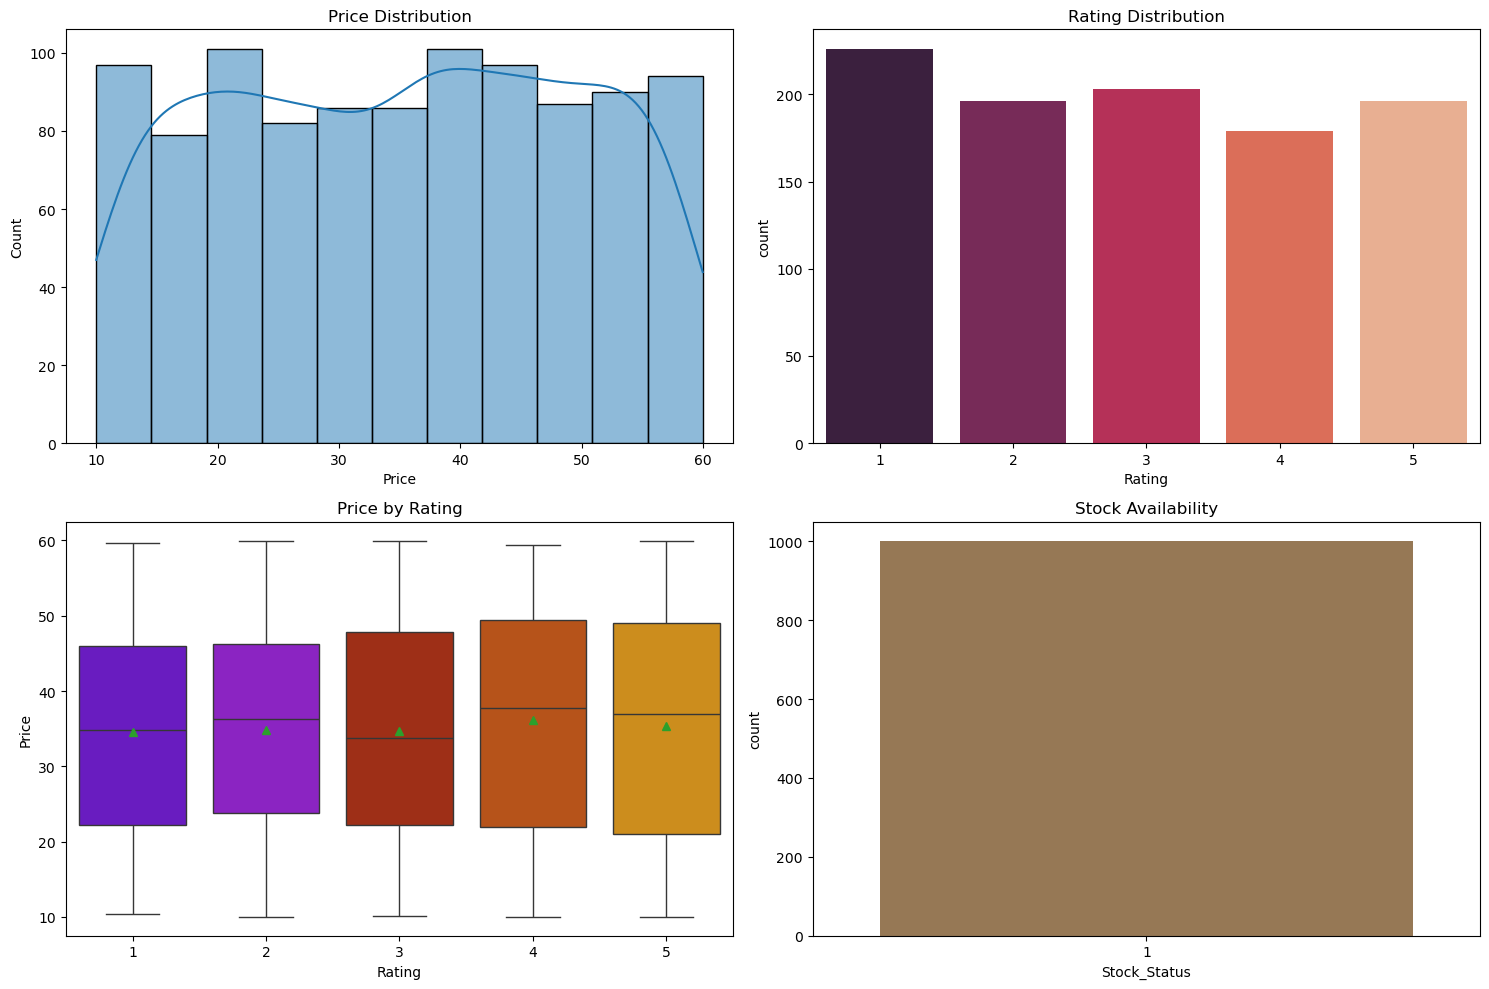

In [6]:
3.#EDA 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Basic stats
print(Books_Clean.describe())

# Visualizations
plt.figure(figsize=(15, 10))

# 1. Price distribution
plt.subplot(2, 2, 1)
sns.histplot(Books_Clean['Price'], kde=True,palette='Blues')
plt.title('Price Distribution')

# 2. Rating distribution
plt.subplot(2, 2, 2)
sns.countplot(x='Rating', data=Books_Clean,palette='rocket')
plt.title('Rating Distribution')

# 3. Price vs Rating
plt.subplot(2, 2, 3)
sns.boxplot(x='Rating', y='Price', data=Books_Clean,showmeans=True,palette='gnuplot')
plt.title('Price by Rating')

# 4. Stock status
plt.subplot(2, 2, 4)
sns.countplot(x='Stock_Status', data=Books_Clean,palette='cubehelix')
plt.title('Stock Availability')

plt.tight_layout()
plt.savefig('Subplot of Books_Data Against Various Drivers',dpi=300,bbox_inches='tight')
plt.show()

# Interactive Plotly (for dashboard later)
fig = px.scatter(Books_Clean, x='Price', y='Rating', color='Rating_Category', hover_data=['Title'])
fig.write_html("Price_vs_Rating.html")  # open in browser



In [ ]:
#4 Model Building and Evaluation

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Clustering: Segment books
features = Books_Clean[['Price', 'Rating', 'Stock_Status']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
Books_Clean['Cluster'] = kmeans.fit_predict(scaled)

# Interpretation
print(Books_Clean.groupby('Cluster')[['Price', 'Rating']].mean())

# Classification: Predict High/Low rating
X = pd.get_dummies(Books_Clean[['Price', 'Stock_Status']], drop_first=True)
y = (Books_Clean['Rating'] >= 4).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Save model
joblib.dump(rf, 'rating_predictor_model.pkl')

d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


             Price    Rating
Cluster                     
0        23.776309  4.034700
1        29.686049  1.407295
2        50.187994  3.336158
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.57      0.58       120
           1       0.38      0.39      0.38        80

    accuracy                           0.50       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.50      0.50      0.50       200

Confusion Matrix:
 [[69 51]
 [49 31]]


['rating_predictor_model.pkl']

Video Link: https://www.loom.com/share/d47a8aa6473e431baa83e101d11ad254